In [12]:
import pandas as pd
import geopandas as gpd
import geemap
import rioxarray as rxr
import pysal
import contextily as ctx
import xarray as xr
import folium
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
warnings.filterwarnings("ignore")

# 🗺️Graficando los materialidades de los techos en Valparaíso.

- **Datos utilizados:** Cartografía Censal de la región de Valparaíso, descargado de [aquí](https://censo2024.ine.gob.cl/resultados/).

Abriendo y analizando el geodataframe.

In [13]:

path = os.path.join("datos", "Cartografia_censo2024_R05", "Cartografia_censo2024_R05.gpkg")
gdf = gpd.read_file(path)

print(gdf.crs)              # sistema de coordenadas
print(gdf.columns.tolist()) # columnas disponibles
print(gdf.shape)            # (n_filas, n_columnas)
gdf.head()

EPSG:4674
['CUT', 'COD_REGION', 'REGION', 'COD_PROVINCIA', 'PROVINCIA', 'COMUNA', 'AREA_C', 'ENTIDAD', 'COD_CATEGORIA', 'CATEGORIA', 'ID_ENTIDAD', 'n_per', 'n_hombres', 'n_mujeres', 'n_edad_0_5', 'n_edad_6_13', 'n_edad_14_17', 'n_edad_18_24', 'n_edad_25_44', 'n_edad_45_59', 'n_edad_60_mas', 'prom_edad', 'n_inmigrantes', 'n_nacionalidad', 'n_pueblos_orig', 'n_afrodescendencia', 'n_lengua_indigena', 'n_religion', 'n_dificultad_ver', 'n_dificultad_oir', 'n_dificultad_mover', 'n_dificultad_cogni', 'n_dificultad_cuidado', 'n_dificultad_comunic', 'n_discapacidad', 'n_estcivcon_casado', 'n_estcivcon_conviviente', 'n_estcivcon_conv_civil', 'n_estcivcon_anul_sep_div', 'n_estcivcon_viudo', 'n_estcivcon_soltero', 'prom_escolaridad18', 'n_asistencia_parv', 'n_asistencia_basica', 'n_asistencia_media', 'n_asistencia_superior', 'n_cine_nunca_curso_primera_infancia', 'n_cine_primaria', 'n_cine_secundaria', 'n_cine_terciaria_maestria_doctorado', 'n_cine_especial_diferencial', 'n_analfabet', 'n_ocupado'

,CUT,COD_REGION,REGION,COD_PROVINCIA,PROVINCIA,COMUNA,AREA_C,ENTIDAD,COD_CATEGORIA,CATEGORIA,...,n_fuente_elect_otro,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro,SHAPE_Length,SHAPE_Area,geometry
0,5102,5,VALPARAÍSO,51,VALPARAÍSO,CASABLANCA,RURAL,LA PLAYA,3,Aldea,...,0.0,0.0,139.0,1.0,0.0,0.0,0.0,0.033093,0.000023,"MULTIPOLYGON (((-71.45067 -33.24369, -71.45036..."
1,5102,5,VALPARAÍSO,51,VALPARAÍSO,CASABLANCA,RURAL,LA PLAYA SUR,3,Aldea,...,2.0,0.0,221.0,1.0,0.0,0.0,1.0,0.044777,0.000059,"MULTIPOLYGON (((-71.44617 -33.24915, -71.4462 ..."
2,5102,5,VALPARAÍSO,51,VALPARAÍSO,CASABLANCA,RURAL,LA VINILLA NORTE,3,Aldea,...,1.0,2.0,184.0,0.0,1.0,0.0,0.0,0.040843,0.000064,"MULTIPOLYGON (((-71.30487 -33.35479, -71.30443..."
3,5102,5,VALPARAÍSO,51,VALPARAÍSO,CASABLANCA,RURAL,LAGUNILLAS,3,Aldea,...,0.0,1.0,164.0,0.0,0.0,0.0,0.0,0.051093,0.000029,"MULTIPOLYGON (((-71.45146 -33.43554, -71.45126..."
4,5102,5,VALPARAÍSO,51,VALPARAÍSO,CASABLANCA,RURAL,QUINTAY,3,Aldea,...,1.0,2.0,251.0,0.0,0.0,0.0,1.0,0.048809,0.000041,"MULTIPOLYGON (((-71.69567 -33.18951, -71.69562..."


In [14]:
gdf.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [15]:
for key in gdf.keys():
    print(key)

CUT
COD_REGION
REGION
COD_PROVINCIA
PROVINCIA
COMUNA
AREA_C
ENTIDAD
COD_CATEGORIA
CATEGORIA
ID_ENTIDAD
n_per
n_hombres
n_mujeres
n_edad_0_5
n_edad_6_13
n_edad_14_17
n_edad_18_24
n_edad_25_44
n_edad_45_59
n_edad_60_mas
prom_edad
n_inmigrantes
n_nacionalidad
n_pueblos_orig
n_afrodescendencia
n_lengua_indigena
n_religion
n_dificultad_ver
n_dificultad_oir
n_dificultad_mover
n_dificultad_cogni
n_dificultad_cuidado
n_dificultad_comunic
n_discapacidad
n_estcivcon_casado
n_estcivcon_conviviente
n_estcivcon_conv_civil
n_estcivcon_anul_sep_div
n_estcivcon_viudo
n_estcivcon_soltero
prom_escolaridad18
n_asistencia_parv
n_asistencia_basica
n_asistencia_media
n_asistencia_superior
n_cine_nunca_curso_primera_infancia
n_cine_primaria
n_cine_secundaria
n_cine_terciaria_maestria_doctorado
n_cine_especial_diferencial
n_analfabet
n_ocupado
n_desocupado
n_fuera_fuerza_trabajo
n_cise_rec_independientes
n_cise_rec_dependientes
n_cise_rec_trabajador_no_remunerado
n_ciuo_1
n_ciuo_2
n_ciuo_3
n_ciuo_4
n_ciuo_5
n

Filtramos por las zonas de interés Viña del Mar y Quilpué.

In [16]:
gdf['PROVINCIA'].unique()

array(['VALPARAÍSO', 'LOS ANDES', 'PETORCA', 'QUILLOTA', 'SAN ANTONIO',
       'SAN FELIPE DE ACONCAGUA', 'MARGA MARGA'], dtype=object)

In [17]:
#gdf = gdf[(gdf['PROVINCIA'] == 'VALPARAÍSO') | (gdf['PROVINCIA'] == 'MARGA MARGA')]
#gdf.to_crs(4326)

<Axes: >

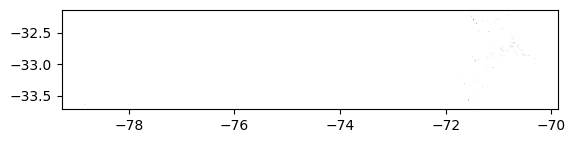

In [18]:
gdf.plot()

Buscamos las llaves del dataframe relacionado con los techos.

In [19]:
techo_keys = [key for key in gdf.columns.tolist() if 'techo' in key]
techo_keys

['n_mat_techo_tejas',
 'n_mat_techo_hormigon',
 'n_mat_techo_zinc',
 'n_mat_techo_fibrocemento',
 'n_mat_techo_fonolita',
 'n_mat_techo_paja',
 'n_mat_techo_precarios',
 'n_mat_techo_sin_cubierta']

In [20]:
gdf.columns.tolist()

['CUT',
 'COD_REGION',
 'REGION',
 'COD_PROVINCIA',
 'PROVINCIA',
 'COMUNA',
 'AREA_C',
 'ENTIDAD',
 'COD_CATEGORIA',
 'CATEGORIA',
 'ID_ENTIDAD',
 'n_per',
 'n_hombres',
 'n_mujeres',
 'n_edad_0_5',
 'n_edad_6_13',
 'n_edad_14_17',
 'n_edad_18_24',
 'n_edad_25_44',
 'n_edad_45_59',
 'n_edad_60_mas',
 'prom_edad',
 'n_inmigrantes',
 'n_nacionalidad',
 'n_pueblos_orig',
 'n_afrodescendencia',
 'n_lengua_indigena',
 'n_religion',
 'n_dificultad_ver',
 'n_dificultad_oir',
 'n_dificultad_mover',
 'n_dificultad_cogni',
 'n_dificultad_cuidado',
 'n_dificultad_comunic',
 'n_discapacidad',
 'n_estcivcon_casado',
 'n_estcivcon_conviviente',
 'n_estcivcon_conv_civil',
 'n_estcivcon_anul_sep_div',
 'n_estcivcon_viudo',
 'n_estcivcon_soltero',
 'prom_escolaridad18',
 'n_asistencia_parv',
 'n_asistencia_basica',
 'n_asistencia_media',
 'n_asistencia_superior',
 'n_cine_nunca_curso_primera_infancia',
 'n_cine_primaria',
 'n_cine_secundaria',
 'n_cine_terciaria_maestria_doctorado',
 'n_cine_especial_

Graficamos los polígonos y construimos una leyenda.

In [21]:
gdf.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [22]:
gdf = gdf.to_crs(epsg=3857)

In [23]:
df_zoi = gpd.read_file(os.path.join('datos', 'incendios', 'hexGrid_250m_incendiosValpo_1985_2026.geojson'))
df_zoi.head()


,grid_id,grid_area,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,id,Nfires,geometry
0,65,162379.76321,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5101,VALPARAÍSO,1.51752,0.030572,1,0,"MULTIPOLYGON (((-71.73794 -33.10754, -71.73823..."
1,68,162379.76321,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5101,VALPARAÍSO,1.51752,0.030572,1,0,"POLYGON ((-71.74261 -33.1003, -71.74273 -33.10..."
2,69,162379.76321,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5101,VALPARAÍSO,1.51752,0.030572,1,0,"MULTIPOLYGON (((-71.73898 -33.09775, -71.7377 ..."
3,70,162379.76321,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5101,VALPARAÍSO,1.51752,0.030572,1,0,"MULTIPOLYGON (((-71.74165 -33.0977, -71.74221 ..."
4,71,162379.76321,5,REGIÓN DE VALPARAÍSO,51,VALPARAÍSO,5101,VALPARAÍSO,1.51752,0.030572,1,0,"MULTIPOLYGON (((-71.73898 -33.09775, -71.73903..."


In [24]:
df_zoi['Nfires'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  8,  7,  9, 10, 11, 13, 14, 16, 12, 17,
       15])

<function matplotlib.pyplot.show(close=None, block=None)>

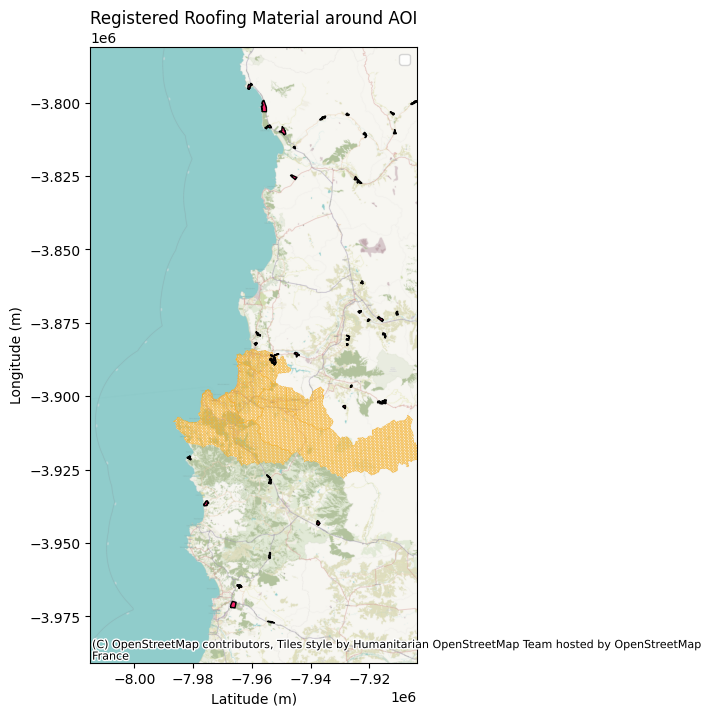

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
df_zoi.to_crs(gdf.crs).plot(ax=ax, facecolor="none", edgecolor="#F5B027", linewidth=0.2, label='AOI')
gdf.plot(ax=ax, color="#F5276C", edgecolor="black")
ctx.add_basemap(ax, zoom=12)
ax.set_xlim(-8015003.34, -7903683.85)
ax.set_title('Registered Roofing Material around AOI')
ax.set_ylabel('Longitude (m)')
ax.set_xlabel('Latitude (m)')
plt.legend(loc='upper right')
plt.show

## Graficando todos las casas registradas en Valparaíso.

In [26]:
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor="#F5B027", edgecolor="#F5B027", label='AOI'),
    Patch(facecolor="#F5276C", edgecolor="black", label='Registered Buildings')
]

<function matplotlib.pyplot.show(close=None, block=None)>

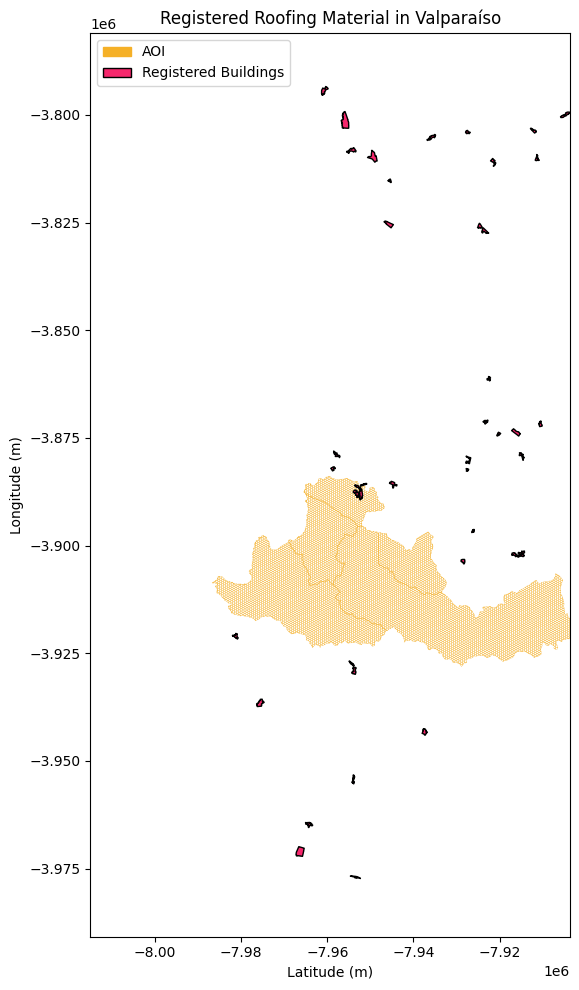

In [27]:
fig, ax = plt.subplots(figsize=(8, 10))
df_zoi.to_crs(gdf.crs).plot(ax=ax, facecolor="none", edgecolor="#F5B027", linewidth=0.2, label='AOI')
gdf.to_crs(gdf.crs).plot(ax=ax, color="#F5276C", edgecolor="black")
#ctx.add_basemap(ax, zoom=9, attribution_size=6)
ax.set_xlim(-8015003.34, -7903683.85)
ax.set_title('Registered Roofing Material in Valparaíso')
ax.set_ylabel('Longitude (m)')
ax.set_xlabel('Latitude (m)')
ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)
fig.tight_layout()
plt.show

## Graficando con datos de Datos para la Resilencia.

In [28]:
gdf_dpr = gpd.read_file(os.path.join('datos', 'catastro.geojson'))

print(gdf_dpr.crs)              # sistema de coordenadas
print(gdf_dpr.columns.tolist()) # columnas disponibles
print(gdf_dpr.shape)            # (n_filas, n_columnas)
gdf_dpr.head()

EPSG:4326
['ID edificio', 'ID Activo', 'Latitud', 'Longitud', 'Rol SII [Comuna-Manzana-Predio]', 'Destino según SII', 'Calidad de Construcción según SII', 'Tipo de ocupación del edificio', 'Zona sísmica según norma NCh 433', 'Área en planta [m²]', 'Área de terreno [m²]', 'Proporción área', 'Avalúo Fiscal Terreno 2021 [CLP]', 'Avalúo Fiscal Construcción Edificio/Oficina Activo 2021', 'Avalúo Fiscal Total 2021 [CLP]', 'Sistema Resistente Lateral', 'Sistema estructural de techo', 'Sistema Protección Sísmica', 'Clasificación Sistema Protección Sísmica', 'Requiere visita o plano', 'Presencia de irregularidad estructural', 'Cota losa de primer piso en la fachada [m]', 'Altura primer piso [m]', 'Altura estimada [m]', 'Número de pisos sobre nivel de suelo', 'Material Predominante', 'Tipo de cubierta del techo', 'Tipo Estructural', 'Presencia de piso liviano en último nivel', 'Presencia de zócalo', 'Cercanía a edificios aledaños', 'Estado de preservación', 'Link Google Maps', 'Comentarios', 'ge

,ID edificio,ID Activo,Latitud,Longitud,Rol SII [Comuna-Manzana-Predio],Destino según SII,Calidad de Construcción según SII,Tipo de ocupación del edificio,Zona sísmica según norma NCh 433,Área en planta [m²],...,Material Predominante,Tipo de cubierta del techo,Tipo Estructural,Presencia de piso liviano en último nivel,Presencia de zócalo,Cercanía a edificios aledaños,Estado de preservación,Link Google Maps,Comentarios,geometry
0,GOB-11_1,GOB-11,-39.820508,-73.229324,10101-10-3,Oficina,Media,Público exclusivo,No Catalogado por tabla NCh 433,409.0,...,Hormigón Armado,Placa metálica,Muros de HA,None,Piso zócalo,Aislado,Bueno,1448 Ruta 206 - Google Maps,None,POINT (-73.22932 -39.82051)
1,AS-87_1,AS-87,-39.814253,-73.223581,10101-1324-17,Comercio,MediaInferior,Arrendado exclusivo,No Catalogado por tabla NCh 433,155.0,...,Albañilería,Pizarreño,Albañilería general,None,No,Muy cercano,Bueno,https://www.google.com/maps/place/Pedro+Aguirr...,None,POINT (-73.22358 -39.81425)
2,TGR-8_1,TGR-8,-39.815366,-73.248615,10101-137-4,AdministraciónPúblicayDefensa,Media,Público compartido,No Catalogado por tabla NCh 433,682.0,...,Hormigón Armado,Placa metálica,Marcos y muros de HA,None,Piso zócalo,Aislado,Bueno,https://www.google.cl/maps/place/San+Carlos+50...,Mismo predio y edificio que SII-54,POINT (-73.24862 -39.81537)
3,JI-939_1,JI-939,-39.806238,-73.220439,10101-1379-1,Otrosnoconsiderados,Media,Público exclusivo,No Catalogado por tabla NCh 433,493.0,...,Madera,Pizarreño,Marcos de madera,None,No,Aislado,Bueno,https://www.google.com/maps/place/Antofagasta+...,None,POINT (-73.22044 -39.80624)
4,AP-928_1,AP-928,-39.806440,-73.220832,10101-1379-2,Otrosnoconsiderados,Media,Público exclusivo,No Catalogado por tabla NCh 433,317.0,...,Madera,Placa metálica,Marcos de madera,None,No,Aislado,Bueno,https://www.google.com/maps/place/Cecof+Norte+...,Cambio de nombre a CECOSF Norte Grande,POINT (-73.22083 -39.80644)


In [29]:
for key in gdf_dpr.keys():
    if 'techo' in key:
        print(key)

Sistema estructural de techo
Tipo de cubierta del techo


In [30]:
gdf_dpr['Sistema estructural de techo'].unique()

array(['Cerchas de madera o galvanizados', 'Envigados', 'Losa de H.A.',
       'S/I', 'Otro'], dtype=object)

In [31]:
gdf.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

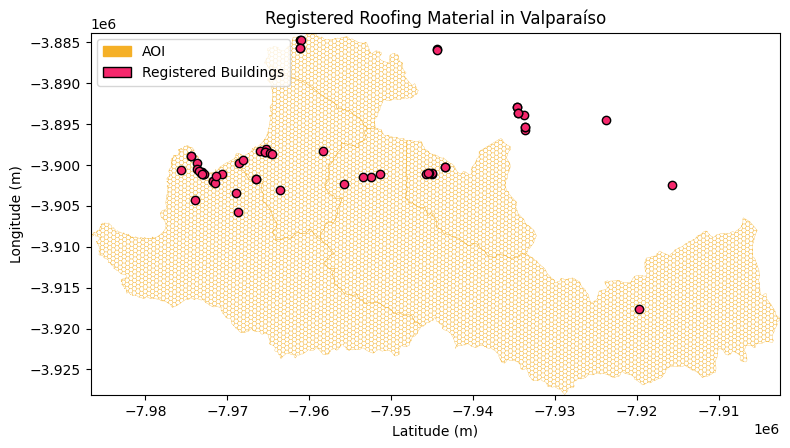

In [32]:
fig, ax = plt.subplots(figsize=(8, 10))
df_zoi.to_crs(gdf.crs).plot(ax=ax, facecolor="none", edgecolor="#F5B027", linewidth=0.2, label='AOI')
gdf_dpr.to_crs(gdf.crs).plot(ax=ax, color="#F5276C", edgecolor="black")
# ctx.add_basemap(ax, zoom=9, attribution_size=6)
minx, miny, maxx, maxy = df_zoi.to_crs(epsg=3857).total_bounds

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title('Registered Roofing Material in Valparaíso')
ax.set_ylabel('Longitude (m)')
ax.set_xlabel('Latitude (m)')
ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)
fig.tight_layout()
plt.show()

# 📊Statistical analysis for roofing materials by provinces in Valparaíso con datos del Censo 2024.

In [33]:
import textwrap

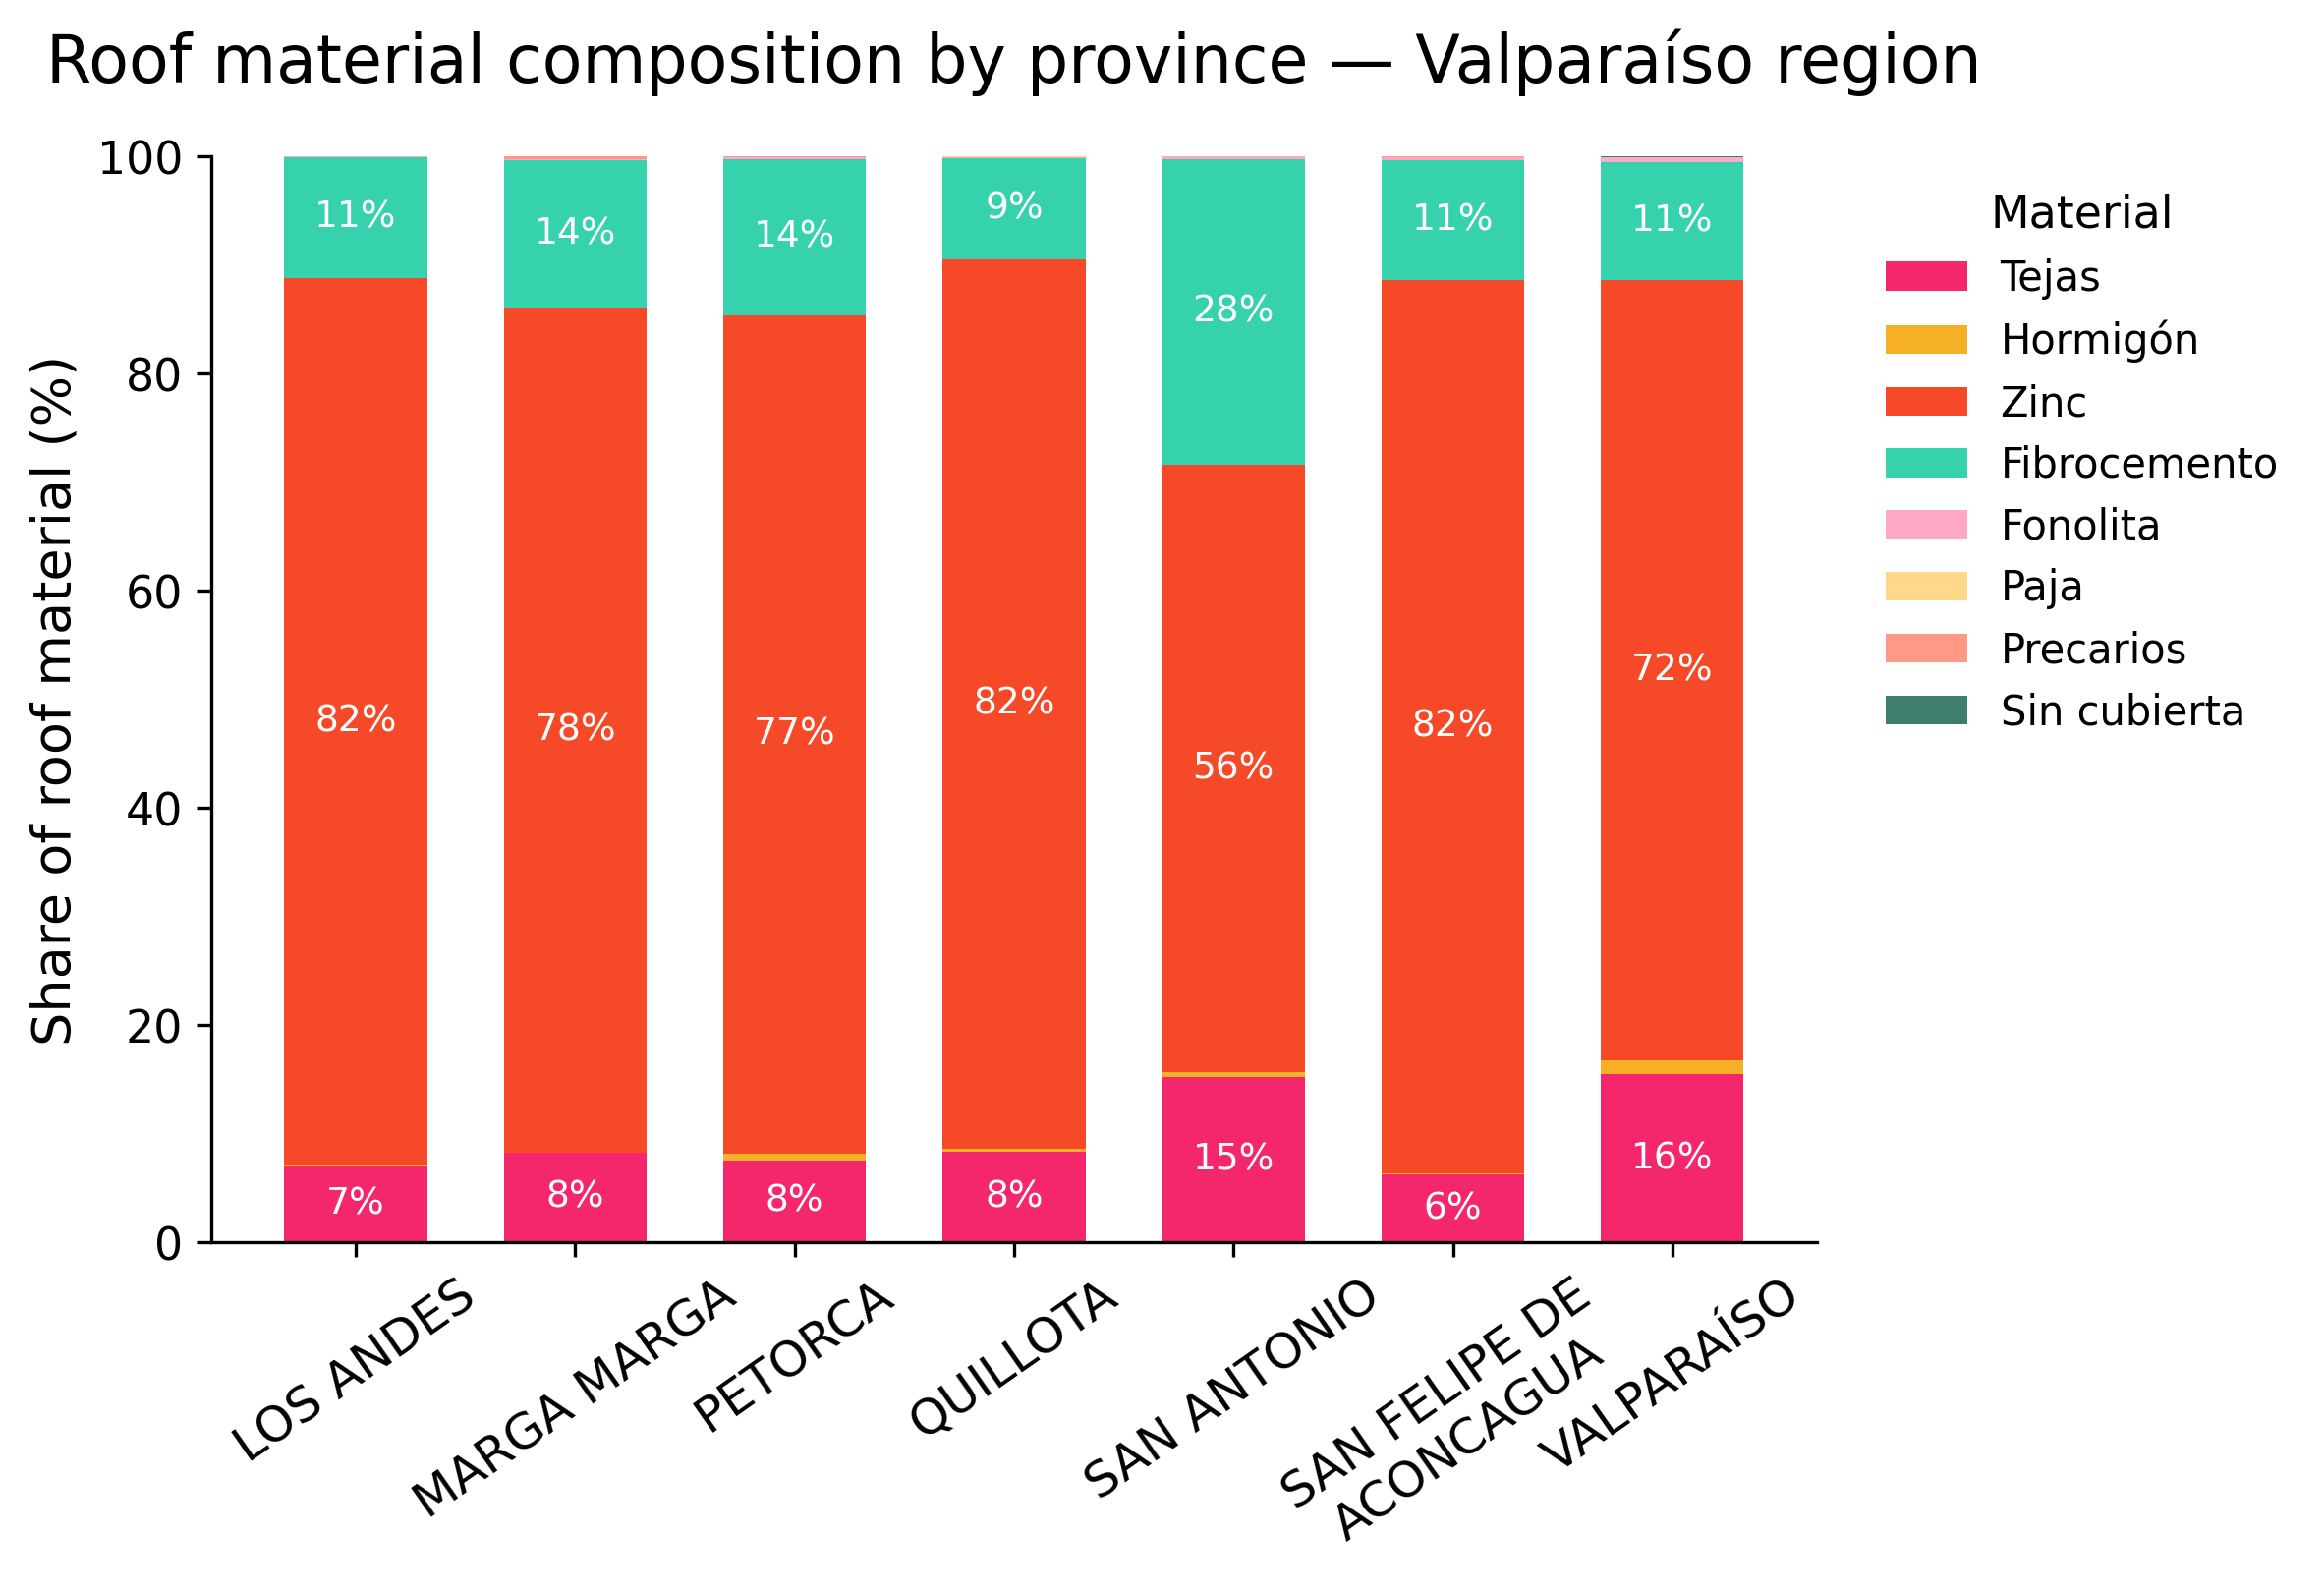

In [ ]:
counts = gdf.groupby("PROVINCIA")[techo_keys].sum().reset_index()

etiquetas = {
    "n_mat_techo_tejas": "Tejas",
    "n_mat_techo_hormigon": "Hormigón",
    "n_mat_techo_zinc": "Zinc",
    "n_mat_techo_fibrocemento": "Fibrocemento",
    "n_mat_techo_fonolita": "Fonolita",
    "n_mat_techo_paja": "Paja",
    "n_mat_techo_precarios": "Precarios",
    "n_mat_techo_sin_cubierta": "Sin cubierta",
}
 
counts = gdf.groupby("PROVINCIA")[techo_keys].sum()
counts = counts.rename(columns=etiquetas)
 
# -----------------------------------------------------------------------
# 3. Normalize each row (province) to sum to 100%
# -----------------------------------------------------------------------
pct = counts.div(counts.sum(axis=1), axis=0) * 100
 
# -----------------------------------------------------------------------
# 4. Style: colors + Helvetica Light
# -----------------------------------------------------------------------
base_colors = ["#F5276C", "#F5B027", "#F54927", "#36D1AD", "#ffa8c5", "#ffd889", "#ff9985", "#3f7e6f"]
colors = [base_colors[i % len(base_colors)] for i in range(len(techo_keys))]
 
#plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.weight"] = "light"
#plt.rcParams["font.sans-serif"] = ["Helvetica", "Helvetica Neue", "Arial", "DejaVu Sans"]
 
# -----------------------------------------------------------------------
# 5. Plot stacked bars
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
 
bottom = np.zeros(len(pct))
material_labels = [etiquetas[c] for c in techo_keys]
 
for material, color in zip(material_labels, colors):
    values = pct[material].values
    bars = ax.bar(pct.index, values, bottom=bottom, color=color, label=material, width=0.65)
 
    # Add % labels inside segments (only if segment is big enough to read)
    for rect, val, base in zip(bars, values, bottom):
        if val > 4:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                base + val / 2,
                f"{val:.0f}%",
                ha="center", va="center",
                fontsize=9, fontweight="light", color="white",
            )
 
    bottom += values
 
ax.set_ylim(0, 100)
ax.set_ylabel("Share of roof material (%)", fontsize=13, fontweight="light")
ax.set_xlabel("")
ax.set_title(
    "Roof material composition by province — Valparaíso region",
    fontsize=16, fontweight="light", pad=18,
)
ax.tick_params(axis="x", labelsize=12, rotation=35)
ax.tick_params(axis="y", labelsize=11)
 
ax.legend(
    title="Material",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11,
)
 
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
 
plt.tight_layout()
ax.set_xticklabels([textwrap.fill(label.get_text(), 18) for label in ax.get_xticklabels()])
plt.savefig(os.path.join("plots", "roof_materials_stacked_by_province.png"), dpi=200, bbox_inches="tight")
plt.show()


## Heatmap/Chloropleth of provinces where there are fires.

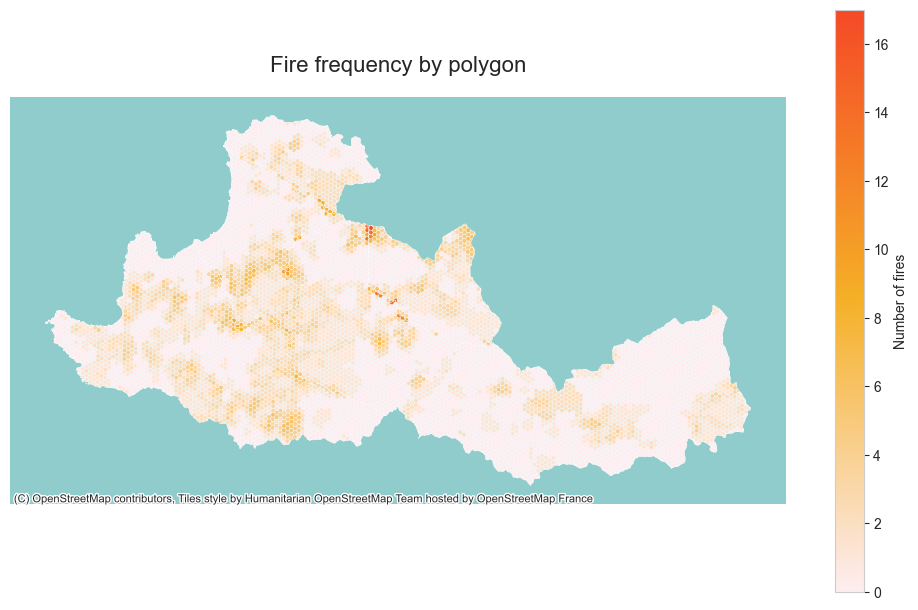

In [49]:
import matplotlib.colors as mcolors

fire_cmap = mcolors.LinearSegmentedColormap.from_list(
    "fire_scale", ["#FDEDF0", "#F5B027", "#F54927"]
)
 
# -----------------------------------------------------------------------
# 2. Plot the choropleth
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))
 
df_zoi.plot(
    column="Nfires",
    cmap=fire_cmap,
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Number of fires", "shrink": 0.6},
    ax=ax,
)
 
ax.set_axis_off()
ax.set_title("Fire frequency by polygon", fontsize=16, fontweight="light", pad=18)
ctx.add_basemap(ax, zoom=12)
 
plt.tight_layout()
plt.savefig(os.path.join("plots", "fires_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()


# Equilibrio del Dataset para training de modelo

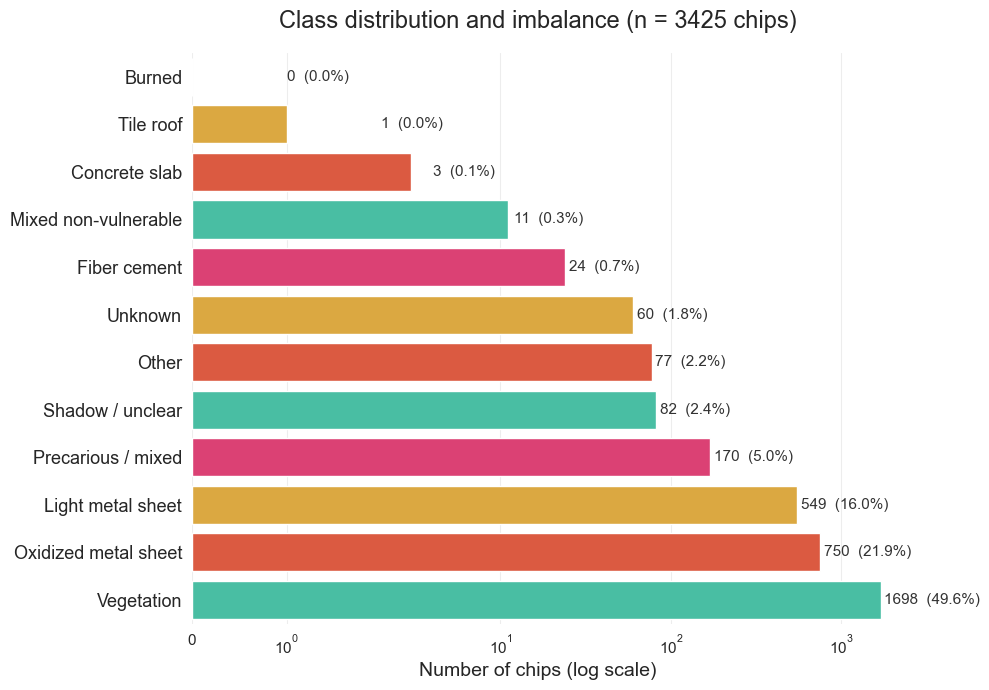

In [48]:
import seaborn as sns

data = {
    "light metal sheet": 549,
    "oxidized metal sheet": 750,
    "burned": 0,
    "fiber cement": 24,
    "concrete slab": 3,
    "tile roof": 1,
    "mixed non-vulnerable": 11,
    "precarious / mixed": 170,
    "vegetation": 1698,
    "shadow / unclear": 82,
    "unknown": 60,
    "other": 77,
}
 
df = pd.DataFrame(list(data.items()), columns=["label", "count"])
df["label"] = df["label"].str.capitalize()  # capitalize only the first letter
df = df.sort_values("count", ascending=True).reset_index(drop=True)
 
total = df["count"].sum()
df["pct"] = df["count"] / total * 100
 
# -----------------------------------------------------------------------
# 2. Requested color scheme, cycled across the 12 classes
# -----------------------------------------------------------------------
base_colors = ["#F5276C", "#F5B027", "#F54927", "#36D1AD"]
palette = [base_colors[i % len(base_colors)] for i in range(len(df))]
 
# -----------------------------------------------------------------------
# 3. Typography: Helvetica Light (with fallback if not installed)
# -----------------------------------------------------------------------
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.weight"] = "light"
plt.rcParams["font.style"] = "normal"
# Fallback in case Helvetica isn't available on the system
plt.rcParams["font.sans-serif"] = ["Helvetica", "Helvetica Neue", "Arial", "DejaVu Sans"]
 
# -----------------------------------------------------------------------
# 4. Horizontal bar chart, log scale to highlight the imbalance
# -----------------------------------------------------------------------
sns.set_style("whitegrid", {"grid.color": "#EDEDED"})
 
fig, ax = plt.subplots(figsize=(10, 7))
 
sns.barplot(
    data=df,
    x="count",
    y="label",
    hue="label",
    palette=palette,
    legend=False,
    ax=ax,
)
 
ax.set_xscale("symlog")  # symlog so the 0 value for 'burned' can still be shown
ax.set_xlabel("Number of chips (log scale)", fontsize=14, fontweight="light")
ax.set_ylabel("")
ax.set_title(
    f"Class distribution and imbalance (n = {total} chips)",
    fontsize=17, fontweight="light", pad=18,
)
 
# Bigger tick labels (class names on the y-axis, counts on the x-axis)
ax.tick_params(axis="y", labelsize=13)
ax.tick_params(axis="x", labelsize=11)
 
# Count + percentage labels at the end of each bar
for i, row in df.iterrows():
    ax.text(
        row["count"] + max(row["count"] * 0.05, 1),
        i,
        f"{row['count']}  ({row['pct']:.1f}%)",
        va="center", fontsize=11, fontweight="light", color="#333333",
    )
 
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig(os.path.join("plots", "class_distribution_chips.png"), dpi=200, bbox_inches="tight")
plt.show()

# Creando un mapa para la vulnerabilidad según el RSH para Valparaíso.

Datos obtenidos de: https://bidat.gob.cl/details/ficha/dataset/shapes-unidades-vecinales-con-indicadores-de-hogares-rsh

In [37]:
path = os.path.join(os.path.join("datos", "202406_shapes_hogares_ant"))
gdf_rsh = gpd.read_file(path)

print(gdf_rsh.crs)              # sistema de coordenadas
print(gdf_rsh.columns.tolist()) # columnas disponibles
print(gdf_rsh.shape)            # (n_filas, n_columnas)
gdf_rsh.head()

EPSG:4674
['objectd', 'cod_rgn', 'cd_prvn', 'cod_cmn', 'nmbr_rg', 'nmbr_pr', 'nmbr_cm', 'id_v_rs', 'uv_cart', 'uv_nmbr', 'prd_ndc', 'ndhet0-4-p', 'ndhet0-4-r', 'ndhet0-4-c', 'ndhet0-4-u', 'ndhet4-5-p', 'ndhet4-5-r', 'ndhet4-5-c', 'ndhet4-5-u', 'ndhet5-6-p', 'ndhet5-6-r', 'ndhet5-6-c', 'ndhet5-6-u', 'ndhet6-7-p', 'ndhet6-7-r', 'ndhet6-7-c', 'ndhet6-7-u', 'ndhet7-8-p', 'ndhet7-8-r', 'ndhet7-8-c', 'ndhet7-8-u', 'ndhet8-9-p', 'ndhet8-9-r', 'ndhet8-9-c', 'ndhet8-9-u', 'ndhet9-1-p', 'ndhet9-1-r', 'ndhet9-1-c', 'ndhet9-1-u', 'totl-ps', 'ttl-rgn', 'ttl-cmn', 'totl-uv', 'geometry']
(6878, 44)


,objectd,cod_rgn,cd_prvn,cod_cmn,nmbr_rg,nmbr_pr,nmbr_cm,id_v_rs,uv_cart,uv_nmbr,...,ndhet8-9-u,ndhet9-1-p,ndhet9-1-r,ndhet9-1-c,ndhet9-1-u,totl-ps,ttl-rgn,ttl-cmn,totl-uv,geometry
0,1.0,15,151,15102,ARICA Y PARINACOTA,ARICA,CAMARONES,151026799,2,2,...,Valores entre 1 y 9,434716.0,5895.0,23,Valores entre 1 y 9,9040611.0,132861.0,682.0,88,"POLYGON ((-69.54506 -18.99123, -69.46649 -19.0..."
1,2.0,15,151,15102,ARICA Y PARINACOTA,ARICA,CAMARONES,151026800,6,6,...,0,434716.0,5895.0,23,Valores entre 1 y 9,9040611.0,132861.0,682.0,25,"POLYGON ((-69.64443 -18.72878, -69.64321 -18.7..."
2,3.0,15,151,15102,ARICA Y PARINACOTA,ARICA,CAMARONES,151026802,4,4,...,Valores entre 1 y 9,434716.0,5895.0,23,Valores entre 1 y 9,9040611.0,132861.0,682.0,90,"POLYGON ((-69.63956 -18.85443, -69.63889 -18.8..."
3,4.0,15,151,15102,ARICA Y PARINACOTA,ARICA,CAMARONES,151026805,5,5,...,Valores entre 1 y 9,434716.0,5895.0,23,Valores entre 1 y 9,9040611.0,132861.0,682.0,65,"POLYGON ((-69.35931 -18.82138, -69.35846 -18.8..."
4,5.0,15,152,15202,ARICA Y PARINACOTA,PARINACOTA,GENERAL LAGOS,152026806,002,COSAPILLA,...,Valores entre 1 y 9,434716.0,5895.0,Valores entre 1 y 9,Valores entre 1 y 9,9040611.0,132861.0,288.0,61,"POLYGON ((-69.41175 -17.86167, -69.4347 -17.86..."


We filter the RSH by Valparaíso.

In [38]:
gdf_rsh_val = gdf_rsh[gdf_rsh['nmbr_rg'] == 'VALPARAISO']

All of the column names that end with `-c` correspond to the number of homes that fall within a certain percentage band (e.g. `ndhet0-4-c` refers to the number of homes in a comuna that fall into the 0-40% vulnerability index) from the RSH per comuna. We select this to have a more precise geographical description of the vulnerability of each comuna. From here, we can plot a heatmap to create potential zones.

In [39]:
bands = [
    'ndhet0-4-c', 'ndhet4-5-c', 'ndhet5-6-c',
    'ndhet6-7-c', 'ndhet7-8-c', 'ndhet8-9-c', 'ndhet9-1-c'
]

Checking out the map for Valparaíso.

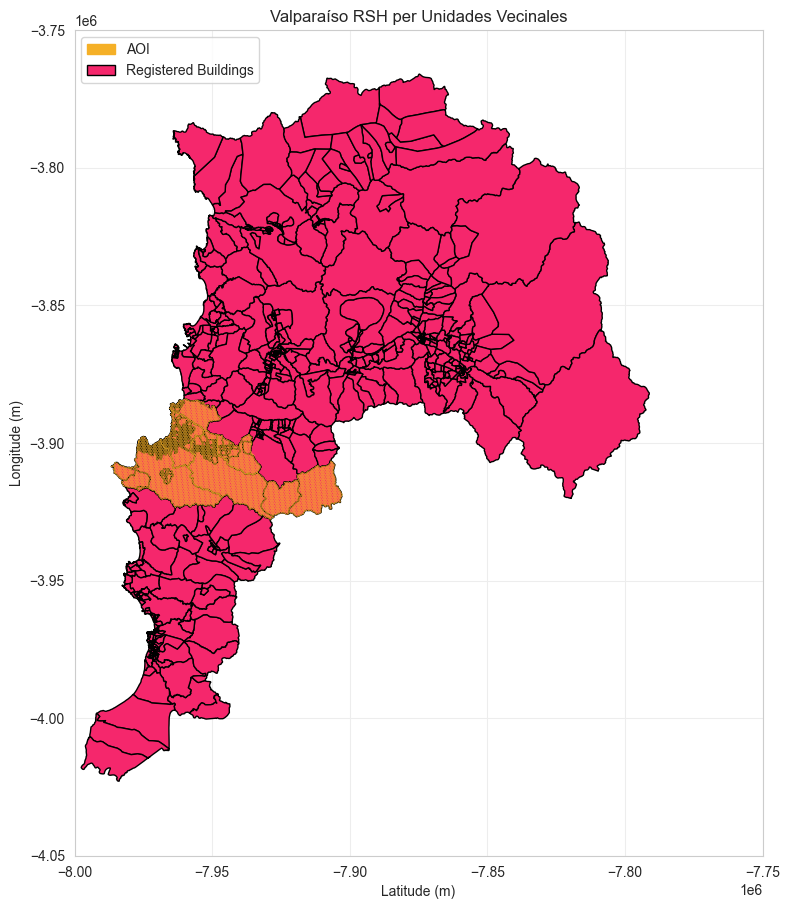

In [40]:
fig, ax = plt.subplots(figsize=(8, 10))
gdf_rsh_val.to_crs(gdf.crs).plot(ax=ax, color="#F5276C", edgecolor="black")
df_zoi.to_crs(gdf.crs).plot(ax=ax, facecolor="none", edgecolor="#F5B027", linewidth=0.2, label='AOI')
# ctx.add_basemap(ax, zoom=9, attribution_size=6)
# minx, miny, maxx, maxy = df_zoi.to_crs(epsg=3857).total_bounds

ax.set_xlim(-8e6, -7.75e6)
ax.set_ylim(-4.05e6, -3.75e6)
ax.set_title('Valparaíso RSH per Unidades Vecinales')
ax.set_ylabel('Longitude (m)')
ax.set_xlabel('Latitude (m)')
ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)
fig.tight_layout()
plt.show()

Cleaning data formats that don't work. Dropping nan rows.

In [41]:
gdf_rsh_val = gdf_rsh_val.dropna(subset=bands).copy()

Looking for strange data formats.

In [42]:
for c in bands:
    weird = gdf_rsh_val.loc[
        ~gdf_rsh_val[c].apply(lambda v: isinstance(v, (int, float))), c
    ].unique()
    if len(weird):
        print(c, "->", weird[:10])

ndhet4-5-c -> ['461' '14072' '2332' '3216' '1173' '2530' '651' '1868' '6875' '1105']
ndhet5-6-c -> ['382' '13042' '2134' '2772' '1031' '2242' '549' '1443' '6357' '793']
ndhet9-1-c -> ['204' '7606' '1100' '1665' '570' '1686' '288' '661' '3715' '430']


In [43]:
print(gdf_rsh_val[bands].dtypes)

ndhet0-4-c    float64
ndhet4-5-c     object
ndhet5-6-c     object
ndhet6-7-c    float64
ndhet7-8-c    float64
ndhet8-9-c    float64
ndhet9-1-c     object
dtype: object


In [44]:
for c in bands:
    gdf_rsh_val[c] = gdf_rsh_val[c].astype(float)

print(gdf_rsh_val[bands].dtypes)

ndhet0-4-c    float64
ndhet4-5-c    float64
ndhet5-6-c    float64
ndhet6-7-c    float64
ndhet7-8-c    float64
ndhet8-9-c    float64
ndhet9-1-c    float64
dtype: object


Plotting the map of vulnerability per comuna, per band.

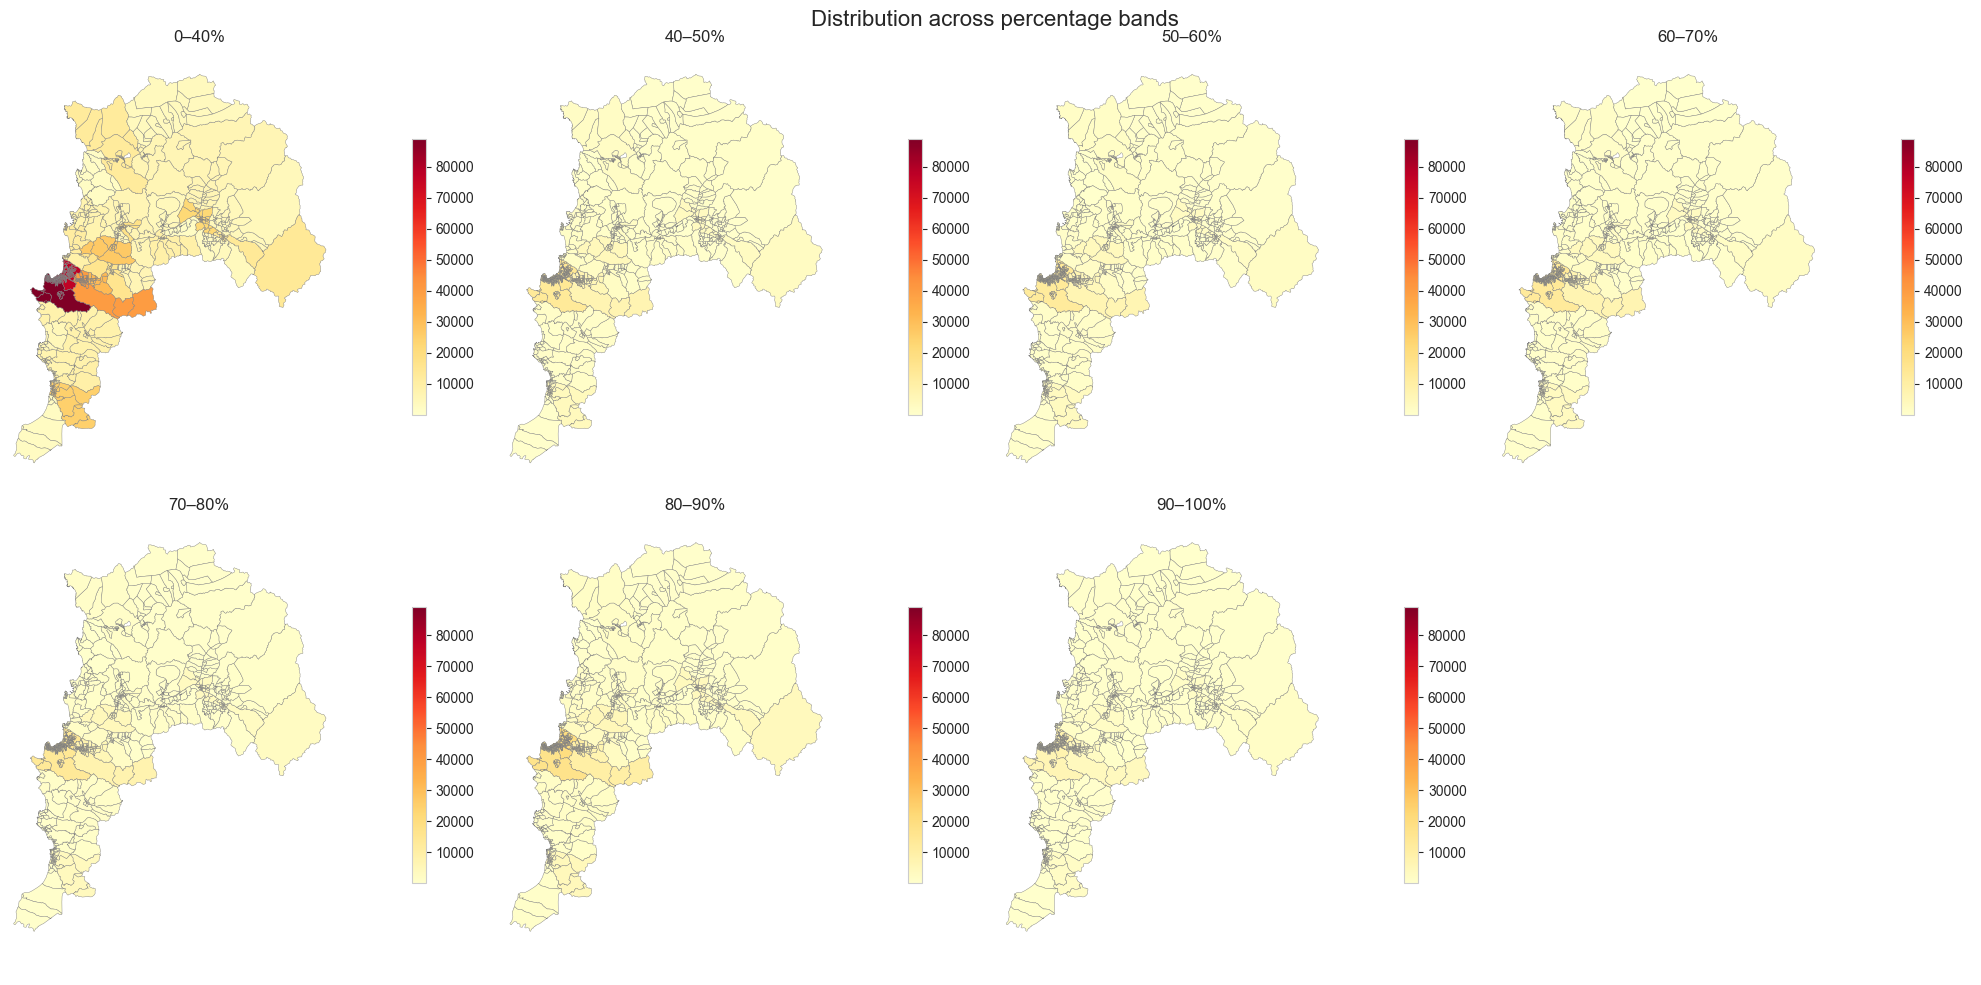

In [45]:
# Your columns in logical order


# Nicer labels
labels = ['0–40%', '40–50%', '50–60%', '60–70%',
          '70–80%', '80–90%', '90–100%']

# Common color scale across all maps for comparability
min_each = [gdf_rsh_val[band].min() for band in bands]
max_each = [gdf_rsh_val[band].max() for band in bands]

vmin = min(min_each)
vmax = max(max_each)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, col, lab in zip(axes, bands, labels):
    gdf_rsh_val.to_crs(gdf.crs).plot(
        column=col,
        ax=ax,
        cmap='YlOrRd',
        vmin=vmin, vmax=vmax,
        legend=True,
        legend_kwds={'shrink': 0.6},
        edgecolor='grey', linewidth=0.3,
        missing_kwds={'color': 'lightgrey'}
    )
    ax.set_title(lab, fontsize=12)
    ax.axis('off')
    ax.set_xlim(-8e6, -7.75e6)
    ax.set_ylim(-4.05e6, -3.75e6)

# Hide the unused 8th subplot
axes[-1].axis('off')

fig.suptitle('Distribution across percentage bands', fontsize=16)
plt.tight_layout()
plt.show()

In [53]:
gdf.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [58]:
"""
Vulnerability choropleth for Valparaíso comunas
-------------------------------------------------
Input: a GeoDataFrame `gdf` (one row per comuna, with geometry) that has
household counts by RSH socioeconomic percentile band:

    ndhet0-4-c  -> households in the  0-40% band (most vulnerable)
    ndhet4-5-c  -> households in the 40-50% band
    ndhet5-6-c  -> households in the 50-60% band
    ndhet6-7-c  -> households in the 60-70% band
    ndhet7-8-c  -> households in the 70-80% band
    ndhet8-9-c  -> households in the 80-90% band
    ndhet9-1-c  -> households in the 90-100% band (least vulnerable)

Method
------
1. Each band is collapsed to its midpoint percentile (0-40 -> 20, 40-50 -> 45, ...).
2. For each comuna, take the household-count-weighted average of those
   midpoints. This reconstructs an estimated *average socioeconomic
   percentile* for the comuna (0-100, higher = wealthier), rather than
   throwing away information by only looking at one band.
3. Invert it (100 - value) into a Vulnerability Index: 0 = least
   vulnerable, 100 = most vulnerable. This makes "dark = vulnerable"
   read naturally on the map.
4. Classify into 5 groups with natural breaks (Jenks) rather than a
   continuous ramp -- continuous gradients hide clusters, discrete
   classes reveal them.

Replace the "LOAD YOUR DATA" section with however you already build `gdf`.
"""

import geopandas as gpd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. LOAD YOUR DATA -- replace this with your existing gdf
# ------------------------------------------------------------------
# gdf = gpd.read_file("your_file.geojson")
# gdf must have a valid geometry column and the 7 band columns listed above.

BAND_MIDPOINTS = {
    "ndhet0-4-c": 20,   # 0-40%
    "ndhet4-5-c": 45,   # 40-50%
    "ndhet5-6-c": 55,   # 50-60%
    "ndhet6-7-c": 65,   # 60-70%
    "ndhet7-8-c": 75,   # 70-80%
    "ndhet8-9-c": 85,   # 80-90%
    "ndhet9-1-c": 95,   # 90-100%
}

def add_vulnerability_index(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    cols = list(BAND_MIDPOINTS.keys())
    missing = [c for c in cols if c not in gdf.columns]
    if missing:
        raise KeyError(f"Missing expected band columns: {missing}")

    gdf = gdf.copy()
    gdf["total_hogares"] = gdf[cols].sum(axis=1)

    # Weighted average socioeconomic percentile (0-100, higher = wealthier)
    weighted_sum = sum(gdf[col] * mid for col, mid in BAND_MIDPOINTS.items())
    gdf["percentil_promedio"] = weighted_sum / gdf["total_hogares"]

    # Vulnerability index: invert so higher = more vulnerable
    gdf["indice_vulnerabilidad"] = 100 - gdf["percentil_promedio"]

    # Simple sanity-check alternative: share of households in the bottom band
    gdf["pct_vulnerable_0_40"] = gdf["ndhet0-4-c"] / gdf["total_hogares"] * 100

    return gdf


def plot_vulnerability_map(
    gdf: gpd.GeoDataFrame,
    value_col: str = "indice_vulnerabilidad",
    label_col: str | None = None,   # e.g. "comuna" if you have a name column
    k: int = 5,
    out_path: str = "valparaiso_vulnerability_map.png",
):
    fig, ax = plt.subplots(1, 1, figsize=(10, 13))

    gdf.to_crs(3857).plot(
        column=value_col,
        scheme="NaturalBreaks",   # Jenks natural breaks -> highlights clusters
        k=k,
        cmap="RdYlGn_r",          # red = high vulnerability, green = low
        linewidth=0.6,
        edgecolor="black",
        legend=True,
        legend_kwds={
            "title": "Vulnerability\n(0-40% band = higher)",
            "loc": "lower left",
            "fontsize": 9,
            "title_fontsize": 10,
        },
        ax=ax,
    )
    #df_zoi.to_crs(gdf_zoi.crs).plot(ax=ax, facecolor="none", edgecolor="#F5B027", linewidth=0.2, label='AOI')

    #if label_col and label_col in gdf.columns:
    #    for _, row in gdf.iterrows():
    #        pt = row.geometry.representative_point()
    #        ax.annotate(
    #            row[label_col],
    #            xy=(pt.x, pt.y),
    #            fontsize=6,
    #            ha="center",
    #            color="#222222",
    #        )

    ax.set_title(
        "Socioeconomic Vulnerability by Comuna — Región de Valparaíso",
        fontsize=14,
        weight="bold",
    )
    #ctx.add_basemap(ax, zoom=12)
    ax.axis("off")
    ax.set_xlim(-8e6, -7.75e6)
    ax.set_ylim(-4.05e6, -3.75e6)
    plt.tight_layout()
    plt.savefig(os.path.join("plots", out_path), dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved map to {out_path}")

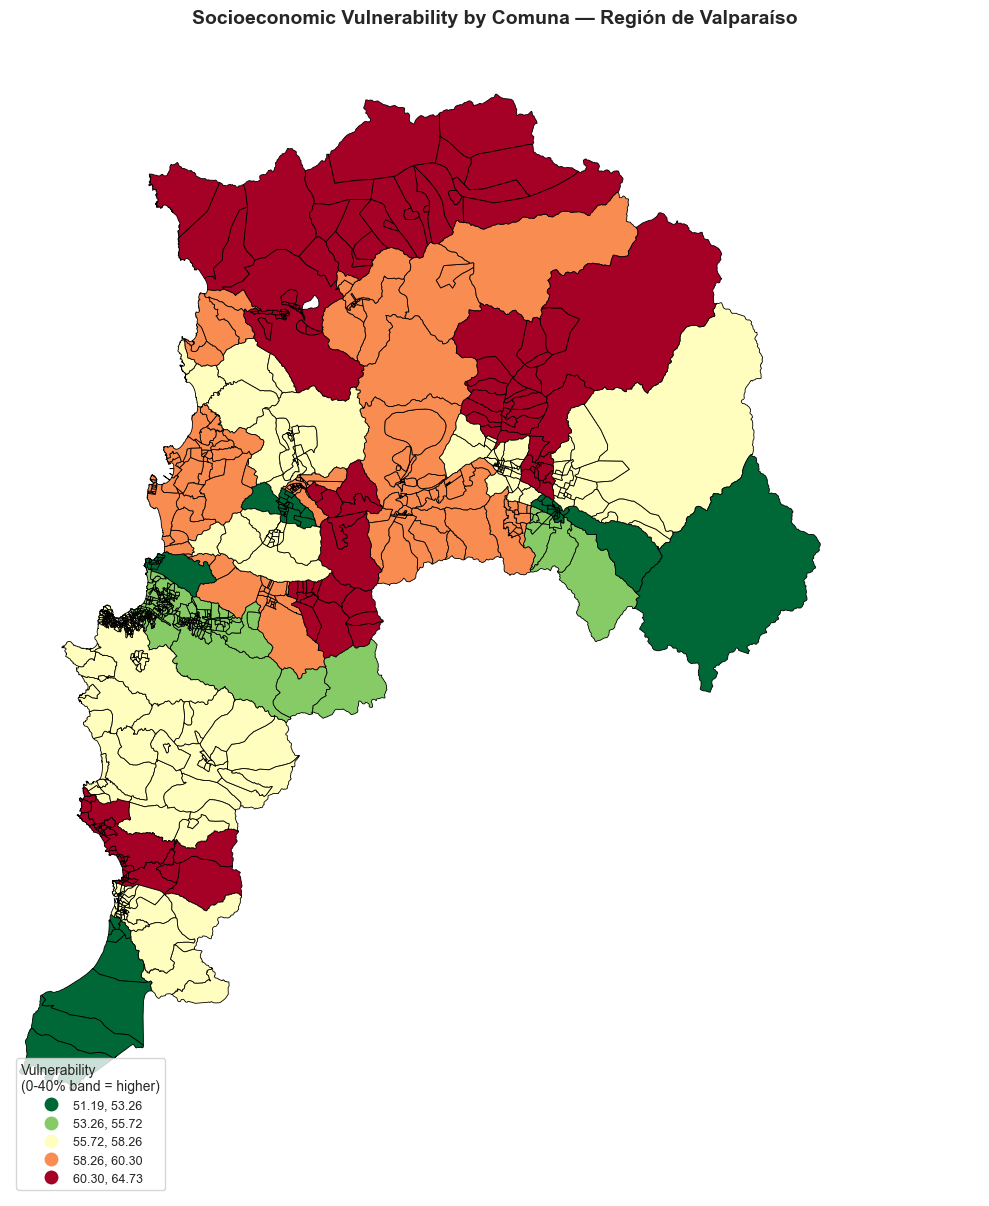

Saved map to valparaiso_vulnerability_map.png


In [59]:
gdf_rsh_val_plot = add_vulnerability_index(gdf_rsh_val)          # noqa: F821 -- gdf comes from your data-loading step
plot_vulnerability_map(gdf_rsh_val_plot, label_col="nmbr_cm")  # set label_col=None if you don't have comuna names